# EcoSort Waste Management Assistant
# Module 8 Summative Lab

## Overview

You are a data scientist at "EcoSort," a technology company that specializes in developing AI solutions for waste management. EcoSort has partnered with Metro City's waste management department to develop an intelligent waste management assistant that can help residents properly dispose of waste items so less time is spent sorting material at facilities.

This assistant needs to:

1. Identify waste materials from images uploaded by residents (CNN)
2. Classify waste items based on text descriptions provided by residents (RNN/Transformer)
3. Generate specific recycling instructions based on identified waste type and city policies (Generative Transformer with RAG)

Your task is to build this integrated system using the RealWaste dataset along with generated text data that simulates real-world waste management operations.

## Part 1: Dataset Exploration and Preparation

In this section, you will explore and prepare the datasets for your models.

### 1.1 Load and Explore the RealWaste Dataset

In [42]:
# Import necessary libraries
import os
import pathlib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from collections import Counter
import json


import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

import sentence_transformers
from sentence_transformers import SentenceTransformer

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

TODO: Load and explore the RealWaste dataset
- Dataset structure
- Distribution of waste categories
- Image characteristics (resolution, quality, background)

Your code here

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Define the path to the RealWaste dataset

data_dir = pathlib.Path(
    "/content/drive/MyDrive/WasteManagement/RealWaste"
)

print("Dataset folder exists:", data_dir.exists())

print("Dataset folders:", os.listdir(data_dir))

Dataset folder exists: True
Dataset folders: ['Food Organics', 'Plastic', 'Metal', 'Glass', 'Cardboard', 'Vegetation', 'Miscellaneous Trash', 'Paper', 'Textile Trash']


In [4]:
# Explore the dataset folders and count images in each category

for category in sorted(os.listdir(data_dir)):
    category_path = data_dir / category

    if category_path.is_dir():
        image_count = len([
            file for file in category_path.iterdir()
            if file.is_file()
        ])

        print(f"{category}: {image_count} images")

Cardboard: 461 images
Food Organics: 411 images
Glass: 420 images
Metal: 790 images
Miscellaneous Trash: 495 images
Paper: 500 images
Plastic: 921 images
Textile Trash: 318 images
Vegetation: 436 images


There is class imbalance per the above cell.

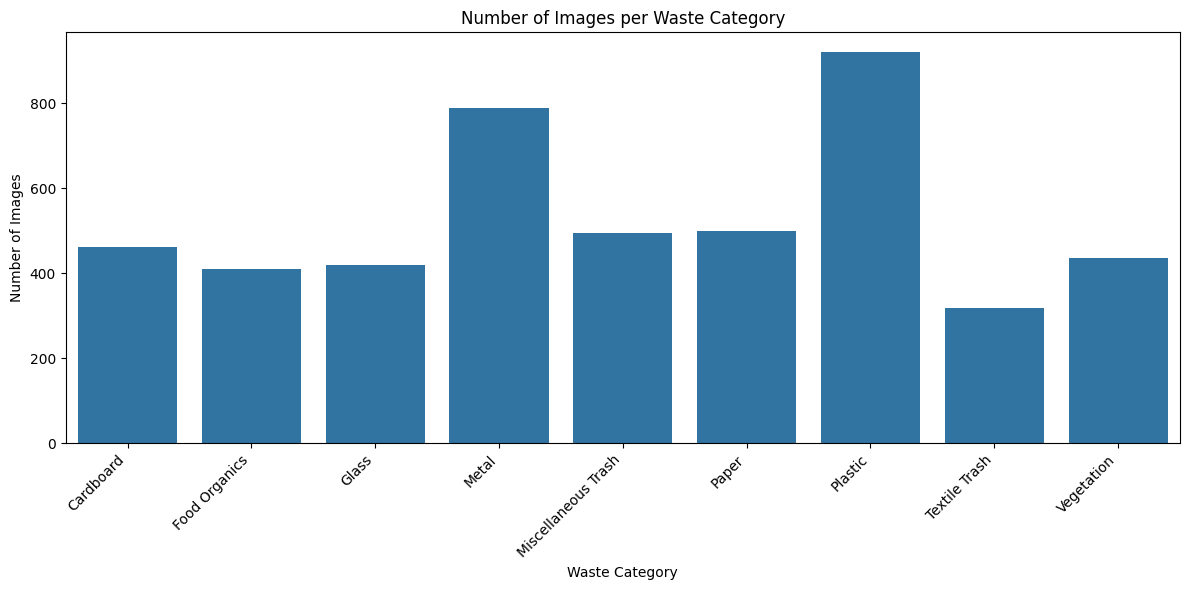

In [5]:

# Visualize the number of images in each category

categories = []
image_counts = []

for category in sorted(os.listdir(data_dir)):
    category_path = data_dir / category

    if category_path.is_dir():
        count = len([
            file for file in category_path.iterdir()
            if file.is_file()
        ])

        categories.append(category)
        image_counts.append(count)

plt.figure(figsize=(12, 6))
sns.barplot(x=categories, y=image_counts)

plt.title("Number of Images per Waste Category")
plt.xlabel("Waste Category")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

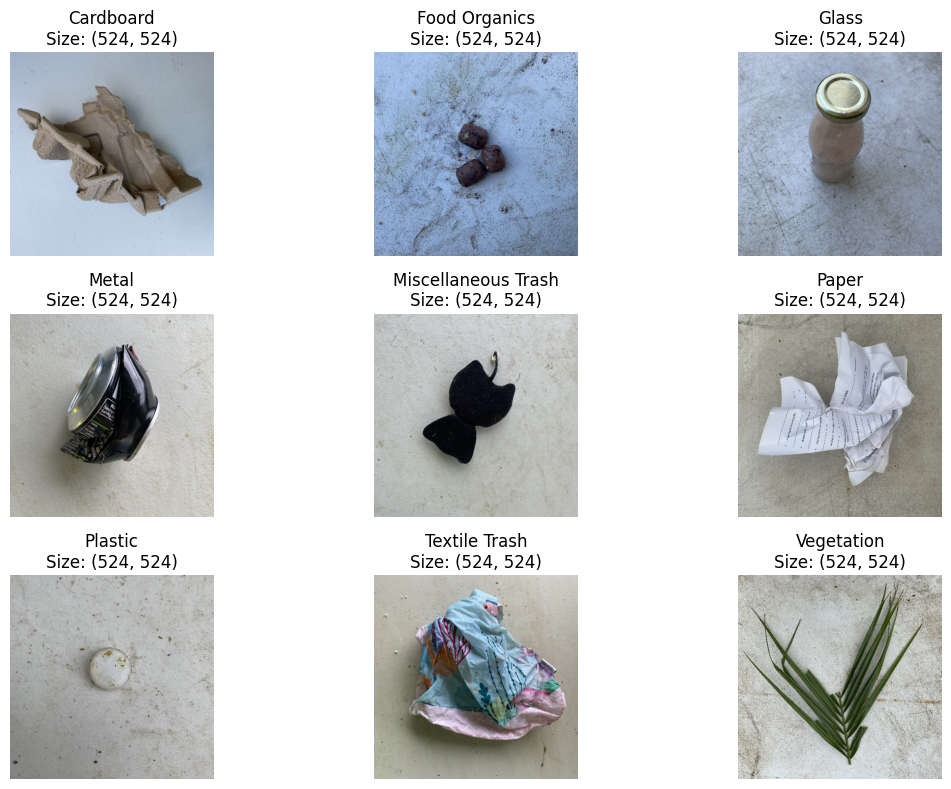

In [7]:
# Exploring image characteristics
categories = sorted([
    folder.name for folder in data_dir.iterdir()
    if folder.is_dir()
])

plt.figure(figsize=(12, 8))

for i, category in enumerate(categories):
    category_path = data_dir / category

    image_files = [
        file for file in category_path.iterdir()
        if file.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ]

    image_path = random.choice(image_files)

    image = Image.open(image_path)

    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(f"{category}\nSize: {image.size}")
    plt.axis("off")

plt.tight_layout()
plt.show()

### Image observations
Resolution - All displayed images are 524 × 524 pixels.
Background - Mostly light grey or white surfaces.
Lighting - Lighting and shadows vary slightly between images.
Potential overlap - Some materials may look similar, particularly paper/cardboard.

In [8]:
# Double check if all the images have the same dimensions
# Check image dimensions across all categories

image_sizes = []

for category in categories:
    category_path = data_dir / category

    for image_path in category_path.iterdir():
        if image_path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
            try:
                with Image.open(image_path) as img:
                    image_sizes.append(img.size)

            except Exception as e:
                print(f"Could not read {image_path.name}: {e}")

# Count the different image dimensions
size_counts = pd.Series(image_sizes).value_counts()

print("Number of images checked:", len(image_sizes))
print("\nImage dimensions and their frequencies:")
print(size_counts)

Number of images checked: 4752

Image dimensions and their frequencies:
(524, 524)    4752
Name: count, dtype: int64


All images have a uniform resolution of 524 × 524 pixels.

### 1.2 Explore Text Datasets

TODO: Load and explore the waste description text data
- Load waste_descriptions.csv
- Analyze vocabulary and structure
- Understand the distribution of categories

### Your code here

In [10]:
# Load the waste description dataset

text_data_path = pathlib.Path(
    "/content/drive/MyDrive/WasteManagement/waste_descriptions.csv"
)

text_df = pd.read_csv(text_data_path)

text_df.head()

,description,category,disposal_instruction,common_confusion,material_composition
0,soiled silver tablecloth,Textile Trash,Look for textile recycling programs in your area.,NaN,"Fabric made from natural or synthetic fibers, ..."
1,folded glass bottle leaking,Glass,"Remove caps, lids, and corks before recycling.",NaN,"Silica-based material, may contain additives f..."
2,large Supermarket vegetable waste with food re...,Food Organics,"If no compost available, place in general waste.",NaN,Biodegradable matter derived from plant or ani...
3,intact floral carpet piece,Textile Trash,Look for textile recycling programs in your area.,NaN,"Fabric made from natural or synthetic fibers, ..."
4,empty fun-sized purple apple core,Food Organics,Keep separate from recyclable materials.,Meat and dairy products may be restricted in s...,Biodegradable matter derived from plant or ani...


In [11]:
# Examine the structure of the text dataset

print("Dataset shape:", text_df.shape)

print("\nColumn information:")
text_df.info()

print("\nMissing values per column:")
print(text_df.isnull().sum())

Dataset shape: (5000, 5)

Column information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   description           5000 non-null   object
 1   category              5000 non-null   object
 2   disposal_instruction  5000 non-null   object
 3   common_confusion      2496 non-null   object
 4   material_composition  5000 non-null   object
dtypes: object(5)
memory usage: 195.4+ KB

Missing values per column:
description                0
category                   0
disposal_instruction       0
common_confusion        2504
material_composition       0
dtype: int64


Number of unique categories: 9

Number of descriptions per category:
category
Vegetation             600
Textile Trash          586
Cardboard              584
Miscellaneous Trash    578
Plastic                569
Glass                  551
Food Organics          518
Metal                  508
Paper                  506
Name: count, dtype: int64


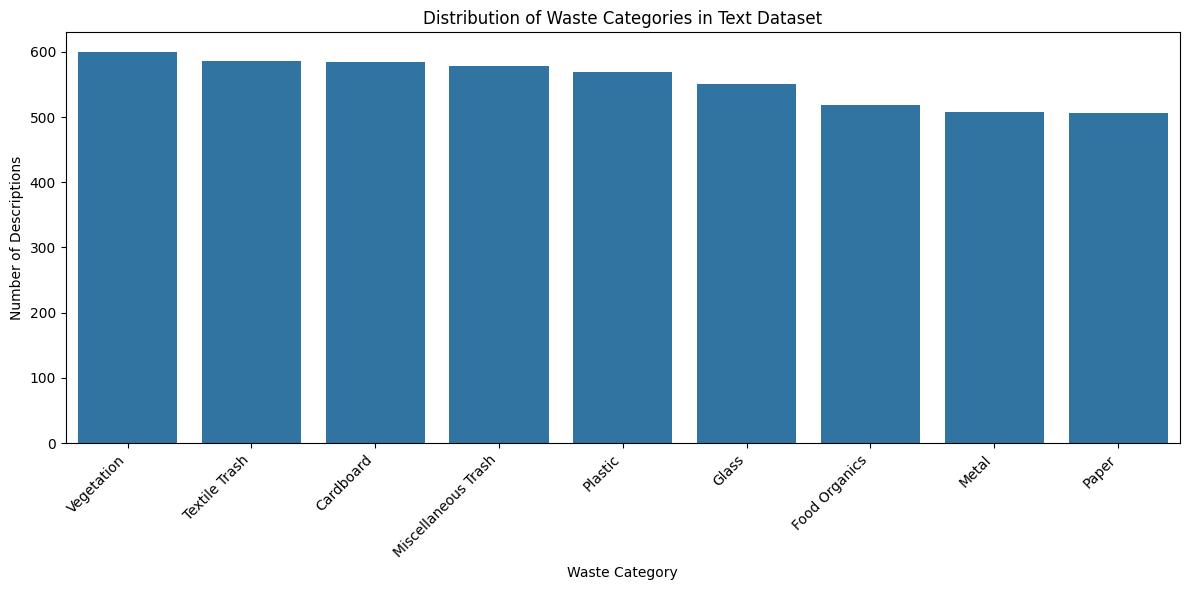

In [12]:
# Analyze the distribution of waste categories

category_counts = text_df['category'].value_counts()

print("Number of unique categories:", text_df['category'].nunique())

print("\nNumber of descriptions per category:")
print(category_counts)

# Visualize category distribution
plt.figure(figsize=(12, 6))

sns.countplot(
    data=text_df,
    x='category',
    order=category_counts.index
)

plt.title("Distribution of Waste Categories in Text Dataset")
plt.xlabel("Waste Category")
plt.ylabel("Number of Descriptions")
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

The distribution is relatively balanced, with a difference of only 94 descriptions between the largest and smallest categories.

In [13]:
#Explore description length and vocabulary structure

# Analyze the length of waste descriptions

text_df['description_length'] = text_df['description'].apply(
    lambda x: len(str(x).split())
)

print("Description length statistics:")
print(text_df['description_length'].describe())

Description length statistics:
count    5000.000000
mean        4.854000
std         1.549956
min         1.000000
25%         4.000000
50%         5.000000
75%         6.000000
max        10.000000
Name: description_length, dtype: float64


In [15]:
# Analyze the most frequent words in waste descriptions

# Combine all descriptions into one text string
all_descriptions = " ".join(text_df['description'].astype(str))

# Convert text to lowercase and split into individual words
words = all_descriptions.lower().split()

# Count word frequencies
word_counts = Counter(words)

# Display the 20 most frequent words
print("20 Most Frequent Words:")
print(word_counts.most_common(20))

20 Most Frequent Words:
[('with', 727), ('glass', 424), ('empty', 348), ('bottle', 342), ('food', 316), ('paper', 316), ('box', 313), ('residue', 309), ('plastic', 251), ('brand', 247), ('metal', 241), ('dry', 211), ('new', 196), ('soiled', 189), ('crumpled', 189), ('medium', 187), ('orange', 186), ('stained', 185), ('intact', 184), ('broken', 184)]


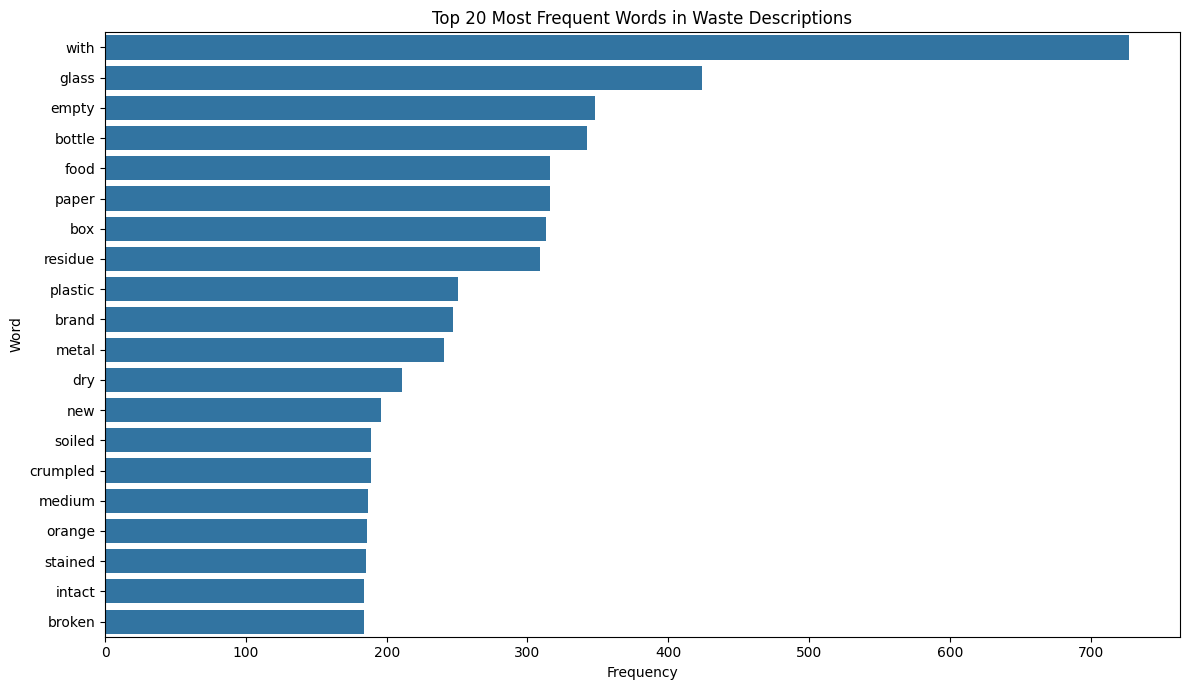

In [17]:
# Visualize the 20 most frequent words

top_words = word_counts.most_common(20)

words_df = pd.DataFrame(
    top_words,
    columns=['Word', 'Frequency']
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=words_df,
    x='Frequency',
    y='Word'
)

plt.title("Top 20 Most Frequent Words in Waste Descriptions")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.tight_layout()
plt.show()

In [18]:
# Display sample descriptions from each waste category

for category in sorted(text_df['category'].unique()):
    print(f"\n--- {category} ---")

    samples = text_df.loc[
        text_df['category'] == category,
        'description'
    ].head(3)

    for description in samples:
        print("-", description)


--- Cardboard ---
- Designer egg carton
- stained red cardboard sleeve with label attached
- new regular-sized purple cardboard tray

--- Food Organics ---
- large Supermarket vegetable waste with food residue
- empty fun-sized purple apple core
- wet compact orange peel with label attached

--- Glass ---
- folded glass bottle leaking
- broken glass container
- clean red wine bottle with food residue

--- Metal ---
- wrinkled metal cutlery with food residue
- partial large purple metal pipe
- used regular-sized striped bottle cap with contents

--- Miscellaneous Trash ---
- gold cigarette butt
- crumpled rubber band
- broken mini Eco-Friendly toy

--- Paper ---
- wrinkled newspaper
- new tissue paper
- clean mini Brand A paper towel

--- Plastic ---
- wrinkled pink takeout container with product remaining
- full black clamshell packaging with food residue
- folded massive yellow milk jug

--- Textile Trash ---
- soiled silver tablecloth
- intact floral carpet piece
- clean small bed s

### TODO: Load and explore the waste policy documents
### - Load waste_policy_documents.csv
### - Understand document organization and language


In [21]:

# Specify the JSON file path
policy_data_path = pathlib.Path(
    "/content/drive/MyDrive/WasteManagement/waste_policy_documents.json"
)

# Load the JSON data
with open(policy_data_path, "r", encoding="utf-8") as file:
    policy_data = json.load(file)

# Display the data type and a sample
print("Data type:", type(policy_data))
print("\nSample policy data:")
print(policy_data[:2] if isinstance(policy_data, list) else policy_data)

Data type: <class 'list'>

Sample policy data:
[{'policy_id': 1, 'policy_type': 'Textile Trash Recycling Guidelines', 'categories_covered': ['Textile Trash'], 'effective_date': '2023-11-04', 'document_text': 'TEXTILE RECYCLING GUIDELINES\n\nAcceptable Items:\n- Clean clothing (all conditions)\n- Towels, sheets, and linens\n- Fabric scraps\n- Curtains and cloth napkins\n- Handbags and backpacks made of fabric\n- Soft toys and stuffed animals\n\nNon-Acceptable Items:\n- Wet or moldy textiles\n- Heavily soiled items\n- Carpets and rugs\n- Footwear\n- Items with significant non-textile parts\n\nCollection Method:\nPlace items in dedicated textile recycling bins or donate to local thrift stores.\n\nPreparation Instructions:\n- Ensure all items are clean and dry\n- Remove non-textile components when possible\n- Bag similar items together\n\nBenefits:\nTextile recycling conserves resources and reduces landfill waste.', 'jurisdiction': 'Metro City'}, {'policy_id': 2, 'policy_type': 'Glass Recy

In [22]:
# Explore the policy document structure

print("Total policy documents:", len(policy_data))

print("\nAvailable fields:")
print(policy_data[0].keys())

print("\nPolicy types:")

for document in policy_data:
    print("-", document['policy_type'])

Total policy documents: 14

Available fields:
dict_keys(['policy_id', 'policy_type', 'categories_covered', 'effective_date', 'document_text', 'jurisdiction'])

Policy types:
- Textile Trash Recycling Guidelines
- Glass Recycling Guidelines
- Food Organics Recycling Guidelines
- Plastic Recycling Guidelines
- Vegetation Recycling Guidelines
- Cardboard Recycling Guidelines
- Metal Recycling Guidelines
- Paper Recycling Guidelines
- Miscellaneous Trash Recycling Guidelines
- Municipal Waste Guidelines
- Residential Recycling Rules
- Commercial Recycling Standards
- Multi-Unit Building Guidelines
- Community Recycling Program


In [23]:
# Analyze the length of policy documents

for document in policy_data:
    document_text = document['document_text']

    word_count = len(document_text.split())

    print(
        f"{document['policy_type']}: "
        f"{word_count} words"
    )

Textile Trash Recycling Guidelines: 104 words
Glass Recycling Guidelines: 86 words
Food Organics Recycling Guidelines: 98 words
Plastic Recycling Guidelines: 94 words
Vegetation Recycling Guidelines: 94 words
Cardboard Recycling Guidelines: 87 words
Metal Recycling Guidelines: 102 words
Paper Recycling Guidelines: 95 words
Miscellaneous Trash Recycling Guidelines: 97 words
Municipal Waste Guidelines: 100 words
Residential Recycling Rules: 146 words
Commercial Recycling Standards: 102 words
Multi-Unit Building Guidelines: 100 words
Community Recycling Program: 120 words


In [25]:
#Examine the language and organization of a policy
# Display one complete policy document

sample_policy = policy_data[0]

print("Policy:", sample_policy['policy_type'])
print("Jurisdiction:", sample_policy['jurisdiction'])
print("Effective date:", sample_policy['effective_date'])

print("\nDocument content:\n")
print(sample_policy['document_text'])

Policy: Textile Trash Recycling Guidelines
Jurisdiction: Metro City
Effective date: 2023-11-04

Document content:

TEXTILE RECYCLING GUIDELINES

Acceptable Items:
- Clean clothing (all conditions)
- Towels, sheets, and linens
- Fabric scraps
- Curtains and cloth napkins
- Handbags and backpacks made of fabric
- Soft toys and stuffed animals

Non-Acceptable Items:
- Wet or moldy textiles
- Heavily soiled items
- Carpets and rugs
- Footwear
- Items with significant non-textile parts

Collection Method:
Place items in dedicated textile recycling bins or donate to local thrift stores.

Preparation Instructions:
- Ensure all items are clean and dry
- Remove non-textile components when possible
- Bag similar items together

Benefits:
Textile recycling conserves resources and reduces landfill waste.


In [26]:
# Examine the waste categories covered by each policy

for document in policy_data:
    print(f"\nPolicy: {document['policy_type']}")
    print("Categories covered:", document['categories_covered'])


Policy: Textile Trash Recycling Guidelines
Categories covered: ['Textile Trash']

Policy: Glass Recycling Guidelines
Categories covered: ['Glass']

Policy: Food Organics Recycling Guidelines
Categories covered: ['Food Organics']

Policy: Plastic Recycling Guidelines
Categories covered: ['Plastic']

Policy: Vegetation Recycling Guidelines
Categories covered: ['Vegetation']

Policy: Cardboard Recycling Guidelines
Categories covered: ['Cardboard']

Policy: Metal Recycling Guidelines
Categories covered: ['Metal']

Policy: Paper Recycling Guidelines
Categories covered: ['Paper']

Policy: Miscellaneous Trash Recycling Guidelines
Categories covered: ['Miscellaneous Trash']

Policy: Municipal Waste Guidelines
Categories covered: ['Plastic', 'Miscellaneous Trash', 'Vegetation']

Policy: Residential Recycling Rules
Categories covered: ['Plastic', 'Metal', 'Glass', 'Miscellaneous Trash', 'Vegetation']

Policy: Commercial Recycling Standards
Categories covered: ['Food Organics', 'Metal', 'Miscell

### 1.3 Create Data Pipelines

In [28]:
# Run this code to setup the images properly into train, validation, and test sets
# Set your data directory path - update this with your actual path
import pathlib
data_dir = pathlib.Path('/content/drive/MyDrive/WasteManagement/RealWaste')

# Parameters
BATCH_SIZE = 32
IMG_HEIGHT = 224
IMG_WIDTH = 224

# Calculate the total number of classes automatically from the directory structure
num_classes = len([item for item in data_dir.glob('*') if item.is_dir()])
print(f"Number of classes: {num_classes}")

# List all class folders
class_names = sorted([item.name for item in data_dir.glob('*') if item.is_dir()])
print(f"Class names: {class_names}")

# Count all images
image_count = len(list(data_dir.glob('*/*.jpg'))) + len(list(data_dir.glob('*/*.png')))
print(f"Total images found: {image_count}")

# Create a dataset using tf.keras.utils.image_dataset_from_directory
# This will automatically split the data into training and validation sets
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,  # 20% for validation
    subset="training",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical',  # For one-hot encoded labels
    shuffle=True
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,  # 20% for validation
    subset="validation",
    seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical',  # For one-hot encoded labels
    shuffle=True
)

# Create a separate test dataset by taking part of the validation set
# First, let's get the number of batches in the validation set
val_batches = tf.data.experimental.cardinality(validation_ds)
test_dataset = validation_ds.take(val_batches // 2)
validation_ds = validation_ds.skip(val_batches // 2)

print(f"Number of training batches: {tf.data.experimental.cardinality(train_ds)}")
print(f"Number of validation batches: {tf.data.experimental.cardinality(validation_ds)}")
print(f"Number of test batches: {tf.data.experimental.cardinality(test_dataset)}")

# Configure dataset for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
validation_ds = validation_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

Number of classes: 9
Class names: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']
Total images found: 4752
Found 4752 files belonging to 9 classes.
Using 3802 files for training.
Found 4752 files belonging to 9 classes.
Using 950 files for validation.
Number of training batches: 119
Number of validation batches: 15
Number of test batches: 15


In [ ]:
# TODO: Create a text preprocessing pipeline
# - Tokenization
# - Text cleaning
# - Split data into train and test
# - Create embeddings/features

# Your code here

TODO: Create a text preprocessing pipeline
- Tokenization
- Text cleaning
- Split data into train and test
- Create embeddings/features


In [30]:

# 1. Select input features and target
X = text_df['description'].copy()
y = text_df['category'].copy()


# 2. Text cleaning
def clean_text(text):
    # Convert text to lowercase
    text = text.lower()

    # Remove special characters and punctuation
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text


X = X.apply(clean_text)


# 3. Tokenization
# Split each description into individual words
X_tokens = X.apply(lambda text: text.split())

print("Original description:")
print(text_df['description'].iloc[0])

print("\nCleaned description:")
print(X.iloc[0])

print("\nTokenized description:")
print(X_tokens.iloc[0])


# 4. Encode target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)


# 5. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)


# 6. Convert text into numerical features using TF-IDF
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

X_test_tfidf = tfidf_vectorizer.transform(X_test)


# 7. Display pipeline results
print("\n========== PIPELINE RESULTS ==========")

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("Training feature shape:", X_train_tfidf.shape)
print("Testing feature shape:", X_test_tfidf.shape)

print("\nEncoded categories:")
print(label_encoder.classes_)

print("\nSample TF-IDF features:")
print(tfidf_vectorizer.get_feature_names_out()[:20])

Original description:
soiled silver tablecloth

Cleaned description:
soiled silver tablecloth

Tokenized description:
['soiled', 'silver', 'tablecloth']

========== PIPELINE RESULTS ==========
Training samples: 4000
Testing samples: 1000
Training feature shape: (4000, 5000)
Testing feature shape: (1000, 5000)

Encoded categories:
['Cardboard' 'Food Organics' 'Glass' 'Metal' 'Miscellaneous Trash' 'Paper'
 'Plastic' 'Textile Trash' 'Vegetation']

Sample TF-IDF features:
['aerosol' 'aerosol can' 'aluminum' 'aluminum can' 'aluminum foil' 'apple'
 'apple core' 'appliance' 'appliance box' 'artisanal' 'artisanal battery'
 'artisanal branches' 'artisanal chicken' 'artisanal cigarette'
 'artisanal clamshell' 'artisanal curtain' 'artisanal dairy'
 'artisanal drinking' 'artisanal dryer' 'artisanal egg']


In [ ]:
# TODO: Prepare documents for RAG
# - Document preprocessing
# - Create embeddings for retrieval

# Your code here

TODO: Prepare documents for RAG
- Document preprocessing
- Create embeddings for retrieval



In [31]:
# Inspect one complete policy document

sample_policy = policy_data[0]

print("Policy:", sample_policy['policy_type'])
print("Jurisdiction:", sample_policy['jurisdiction'])
print("Effective date:", sample_policy['effective_date'])
print("Categories:", sample_policy['categories_covered'])

print("\nDocument text:\n")
print(sample_policy['document_text'])

Policy: Textile Trash Recycling Guidelines
Jurisdiction: Metro City
Effective date: 2023-11-04
Categories: ['Textile Trash']

Document text:

TEXTILE RECYCLING GUIDELINES

Acceptable Items:
- Clean clothing (all conditions)
- Towels, sheets, and linens
- Fabric scraps
- Curtains and cloth napkins
- Handbags and backpacks made of fabric
- Soft toys and stuffed animals

Non-Acceptable Items:
- Wet or moldy textiles
- Heavily soiled items
- Carpets and rugs
- Footwear
- Items with significant non-textile parts

Collection Method:
Place items in dedicated textile recycling bins or donate to local thrift stores.

Preparation Instructions:
- Ensure all items are clean and dry
- Remove non-textile components when possible
- Bag similar items together

Benefits:
Textile recycling conserves resources and reduces landfill waste.


In [33]:
#RAG document processing and chunking

# Function to clean document text
def clean_document(text):
    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text)

    return text.strip()


#  Function to split documents into chunks
def split_into_chunks(text, chunk_size=150, overlap=30):

    words = text.split()
    chunks = []

    start = 0

    while start < len(words):
        end = start + chunk_size

        chunk = " ".join(words[start:end])
        chunks.append(chunk)

        start += chunk_size - overlap

    return chunks


# Prepare policy documents
rag_documents = []

for document in policy_data:

    # Combine policy metadata and document text
    combined_text = f"""
    Policy: {document['policy_type']}
    Jurisdiction: {document['jurisdiction']}
    Effective Date: {document['effective_date']}
    Categories: {', '.join(document['categories_covered'])}

    {document['document_text']}
    """

    # Clean document
    cleaned_text = clean_document(combined_text)

    # Split into chunks
    chunks = split_into_chunks(cleaned_text)

    # Store each chunk with its metadata
    for i, chunk in enumerate(chunks):

        rag_documents.append({
            'chunk_id': f"{document['policy_id']}_chunk_{i}",
            'policy_type': document['policy_type'],
            'jurisdiction': document['jurisdiction'],
            'categories': document['categories_covered'],
            'text': chunk
        })


# Inspect results
print("Total policy documents:", len(policy_data))
print("Total document chunks:", len(rag_documents))

print("\nSample chunk:")
print(rag_documents[0]['text'])

print("\nSample metadata:")
print({
    key: value
    for key, value in rag_documents[0].items()
    if key != 'text'
})

Total policy documents: 14
Total document chunks: 16

Sample chunk:
Policy: Textile Trash Recycling Guidelines Jurisdiction: Metro City Effective Date: 2023-11-04 Categories: Textile Trash TEXTILE RECYCLING GUIDELINES Acceptable Items: - Clean clothing (all conditions) - Towels, sheets, and linens - Fabric scraps - Curtains and cloth napkins - Handbags and backpacks made of fabric - Soft toys and stuffed animals Non-Acceptable Items: - Wet or moldy textiles - Heavily soiled items - Carpets and rugs - Footwear - Items with significant non-textile parts Collection Method: Place items in dedicated textile recycling bins or donate to local thrift stores. Preparation Instructions: - Ensure all items are clean and dry - Remove non-textile components when possible - Bag similar items together Benefits: Textile recycling conserves resources and reduces landfill waste.

Sample metadata:
{'chunk_id': '1_chunk_0', 'policy_type': 'Textile Trash Recycling Guidelines', 'jurisdiction': 'Metro City', 

In [35]:

!pip -q install sentence-transformers

In [40]:
print("Sentence Transformers version:", sentence_transformers.__version__)


Sentence Transformers version: 5.7.0


In [43]:
#Load the embedding model and generate embeddin

# Load pretrained embedding model
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

#  Extract text from policy chunks
chunk_texts = [doc['text'] for doc in rag_documents]

#  Generate embeddings
document_embeddings = embedding_model.encode(
    chunk_texts,
    convert_to_numpy=True,
    show_progress_bar=True
)

# Inspect embeddings
print("Number of document chunks:", len(chunk_texts))
print("Embedding shape:", document_embeddings.shape)
print("First embedding (first 10 values):")
print(document_embeddings[0][:10])

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Number of document chunks: 16
Embedding shape: (16, 384)
First embedding (first 10 values):
[-0.06384788  0.06413313  0.03941709 -0.01767203  0.05158915  0.03161152
  0.05318851 -0.04363598 -0.10674438  0.04246897]


## Part 2: Waste Material Classification with CNN

In this section, you will build a CNN model to classify waste materials from images.

### 2.1 Preprocess Images

In [ ]:
# TODO: Implement image preprocessing
# - Apply the preprocessing pipeline created earlier

# Your code here

In [45]:

# IMAGE PREPROCESSING FOR CNN


# Create a normalization layer
normalization_layer = tf.keras.layers.Rescaling(1./255)

# Apply normalization to each dataset
train_ds = train_ds.map(
    lambda images, labels: (normalization_layer(images), labels),
    num_parallel_calls=AUTOTUNE
)

validation_ds = validation_ds.map(
    lambda images, labels: (normalization_layer(images), labels),
    num_parallel_calls=AUTOTUNE
)

test_dataset = test_dataset.map(
    lambda images, labels: (normalization_layer(images), labels),
    num_parallel_calls=AUTOTUNE
)

# Prefetch for improved performance
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
validation_ds = validation_ds.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

print("Image preprocessing completed!")

Image preprocessing completed!


In [46]:
# Get one batch from the training dataset
for images, labels in train_ds.take(1):

    print("Image shape:", images.shape)
    print("Label shape:", labels.shape)

    print("Minimum pixel value:", tf.reduce_min(images).numpy())
    print("Maximum pixel value:", tf.reduce_max(images).numpy())

Image shape: (32, 224, 224, 3)
Label shape: (32, 9)
Minimum pixel value: 0.0
Maximum pixel value: 1.0


### 2.2 Implement CNN Model with Transfer Learning

In [ ]:
# TODO: Select an appropriate base model and implement transfer learning
# - Choose from MobileNet, EfficientNet, etc.
# - Add custom classification layers for the 9 waste categories
# - Configure loss function and metrics

# Your code here

In [47]:


# 1. Determine number of classes
num_classes = len(class_names)

# 2. Load pretrained MobileNetV2
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights='imagenet'
)

# 3. Freeze pretrained layers
base_model.trainable = False

# 4. Build custom classification head
inputs = tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# Convert pixel values from [0, 1] to [-1, 1]
x = tf.keras.layers.Rescaling(
    scale=2.0,
    offset=-1.0
)(inputs)

# Extract features using MobileNetV2
x = base_model(x, training=False)

# Reduce spatial dimensions
x = tf.keras.layers.GlobalAveragePooling2D()(x)

# Apply dropout to reduce overfitting
x = tf.keras.layers.Dropout(0.2)(x)

# Classify into 9 waste categories
outputs = tf.keras.layers.Dense(
    num_classes,
    activation='softmax'
)(x)

# 5. Create final model
model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs
)

# 6. Configure loss function and metrics
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 7. Display model architecture
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 9)              │        11,529 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,269,513 (8.66 MB)

 Trainable params: 11,529 (45.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### 2.3 Train and Evaluate the Model

In [ ]:
# TODO: Train the CNN model
# - Use appropriate batch size and epochs
# - Implement regularization to prevent overfitting
# - Monitor training and validation metrics

# Your code here

In [48]:

EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=EPOCHS
)

Epoch 1/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 279s 2s/step - accuracy: 0.5466 - loss: 1.2701 - val_accuracy: 0.6936 - val_loss: 0.8240
Epoch 2/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 184s 2s/step - accuracy: 0.7304 - loss: 0.7535 - val_accuracy: 0.7277 - val_loss: 0.6968
Epoch 3/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 177s 1s/step - accuracy: 0.7772 - loss: 0.6183 - val_accuracy: 0.7574 - val_loss: 0.6515
Epoch 4/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 201s 1s/step - accuracy: 0.8114 - loss: 0.5382 - val_accuracy: 0.7766 - val_loss: 0.6245
Epoch 5/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 175s 1s/step - accuracy: 0.8311 - loss: 0.4864 - val_accuracy: 0.7766 - val_loss: 0.6074
Epoch 6/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 205s 1s/step - accuracy: 0.8464 - loss: 0.4388 - val_accuracy: 0.7915 - val_loss: 0.5842
Epoch 7/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 201s 1s/step - accuracy: 0.8601 - loss: 0.4007 - val_accuracy: 0.7851 - val_loss: 0.5799
Epoch 8/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 204s 2s/step - accuracy: 0.8659 - loss: 0.3763 - val_accu

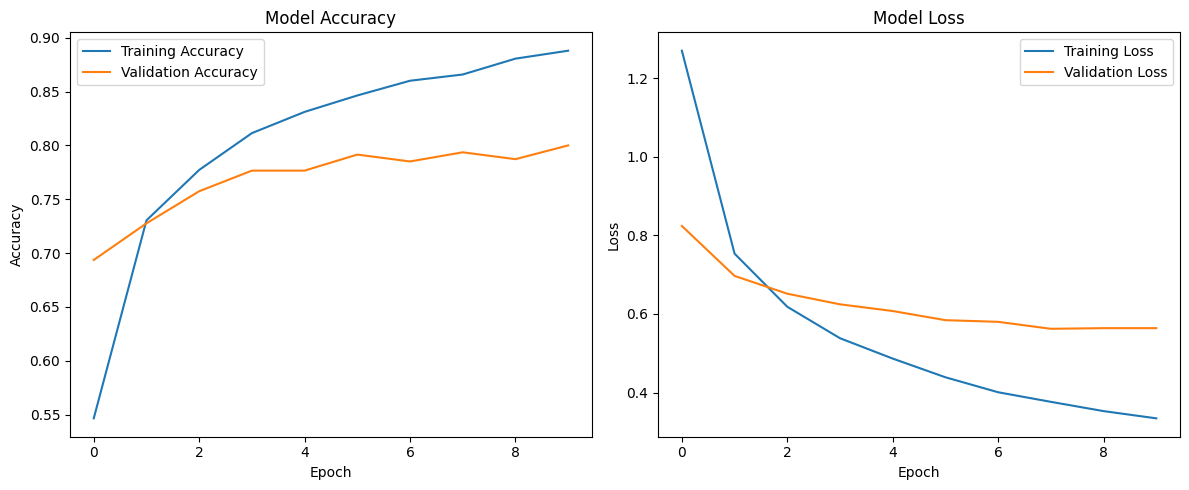

In [49]:

#Visulaize
plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# TODO: Evaluate model performance
# - Calculate accuracy on test set
# - Generate confusion matrix
# - Analyze error patterns

# Your code here

In [50]:
# Evaluate model performance on the test dataset
test_loss, test_accuracy = model.evaluate(test_dataset)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Generate predictions
y_pred_prob = model.predict(test_dataset)

# Convert probabilities into predicted class indices
y_pred = np.argmax(y_pred_prob, axis=1)

print("Predictions shape:", y_pred.shape)

15/15 ━━━━━━━━━━━━━━━━━━━━ 46s 3s/step - accuracy: 0.8000 - loss: 0.5480
Test Loss: 0.5480
Test Accuracy: 0.8000
15/15 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step
Predictions shape: (480,)


### 2.4 Fine-tune the Model

In [ ]:
# TODO: Tune model parameters to improve performance
# - Adjust learning rate
# - Add regularization, dropout
# - Modify architecture if needed

# Your code here

## Part 3: Waste Description Classification

In this section, you will build a text classification model to categorize waste based on descriptions.

### 3.1 Preprocess Text Data

In [ ]:
# TODO: Implement text preprocessing
# - Apply the text preprocessing pipeline created earlier

# Your code here

### 3.2 Implement Text Classification Model

In [ ]:
# TODO: Choose and implement a text classification model
# Option A: Traditional ML model (Naive Bayes, Random Forest, etc.)
# Option B: Fine-tune a transformer-based model (BERT, DistilBERT, etc.)

# Your code here

### 3.3 Train and Evaluate the Model

In [ ]:
# TODO: Train the text classification model
# - Use appropriate training parameters
# - Monitor training progress

# Your code here

In [ ]:
# TODO: Evaluate model performance
# - Calculate accuracy on test set
# - Generate confusion matrix
# - Analyze error patterns

# Your code here

### 3.4 Create Classification Function

In [ ]:
# TODO: Create a function that takes a text description and returns the predicted waste category

def classify_waste_description(description):
    """
    Classifies a waste description into an appropriate category.

    Args:
        description (str): Text description of waste item

    Returns:
        str: Predicted waste category
    """
    # Your code here
    pass

## Part 4: Recycling Instruction Generation with RAG

In this section, you will implement a Retrieval-Augmented Generation (RAG) system to generate recycling instructions.

### 4.1 Preprocess Documents for Retrieval

In [ ]:
# TODO: Prepare documents for retrieval
# - Process policy documents and disposal instructions
# - Create embeddings for efficient retrieval

# Your code here

### 4.2 Implement RAG-based System

In [ ]:
# TODO: Select a pre-trained language model and implement RAG
# - Choose an appropriate language model
# - Create a retrieval mechanism

# Your code here

### 4.3 Adjust and Evaluate the System

In [ ]:
# TODO: Train the RAG-based system
# - Adjust sampling methods/parameters

# Your code here

In [ ]:
# TODO: Evaluate the quality of generated instructions
# - Test with various waste categories
# - Assess relevance and accuracy

# Your code here

### 4.4 Create Instruction Generation Function

In [ ]:
# TODO: Create a function that takes a waste category and generates recycling instructions

def generate_recycling_instructions(waste_category):
    """
    Generates detailed recycling instructions for a given waste category.

    Args:
        waste_category (str): Waste category

    Returns:
        str: Detailed recycling instructions
        list: Relevant policy documents
    """
    # Your code here
    pass

## Part 5: Integrated Waste Management Assistant

In this section, you will integrate all three models into a unified waste management assistant.

### 5.1 Design Integration Architecture

In [ ]:
# TODO: Design an architecture that integrates all three models
# - Create interfaces between components
# - Handle input/output flow

# Your code here

### 5.2 Implement Integrated Assistant

In [ ]:
# TODO: Implement the integrated waste management assistant

def waste_management_assistant(input_data, input_type="image"):
    """
    Integrated waste management assistant that processes either images or text descriptions
    and returns waste classification and recycling instructions.

    Args:
        input_data: Either an image file path/array or a text description
        input_type (str): Type of input - "image" or "text"

    Returns:
        dict: Dictionary containing waste category, confidence, and recycling instructions
    """
    # Your code here
    pass

### 5.3 Evaluate the Integrated System

In [ ]:
# TODO: Evaluate the integrated system on test cases
# - Test with images from test dataset
# - Test with text descriptions from test dataset
# - Assess overall performance

# Your code here

## Submission Guidelines

1. Make sure all code cells are properly commented and annotated
2. Ensure that all functions are implemented and working correctly
3. Verify that all evaluation metrics are calculated and analyzed
4. Double-check that the integrated system works as expected
5. Submit your completed and annotated Jupyter notebook file

Remember to demonstrate your understanding of the underlying concepts and provide justification for your design decisions throughout the notebook.